In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcZ2FicmlcT25lRHJpdmVccHl0aG9uLmdpdGh1Yi5pbw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

C:\Users\gabri\AppData\Local\Temp\ipykernel_20440\3437675630.py:25: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


{"C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\importlib\\_bootstrap.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\importlib\\_bootstrap_external.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\codecs.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\aliases.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\__init__.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\utf_8.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\encodings\\cp1252.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\abc.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\lib\\io.py": 1675805114.0, "C:\\Users\\gabri\\AppData\\Local\\Programs\\Python\\Python310\\li

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [3]:
# trocar essa url pelo caminho da base spam de vocês.
Spam = pd.read_csv("Cadernos Grupo Python\\Validação Cruzada\\spam.csv")
# Separando o rótulo das demais variáveis
XSpam = Spam.loc[:, Spam.columns != "type"]
YSpam = Spam["type"]

In [4]:
# Criação dos k-folds
kfSpam = StratifiedKFold(n_splits=10, shuffle=True, random_state=11).split(XSpam, YSpam)

In [5]:
# Tipo da variável resultado do StratifiedKFold().split()
print(type(kfSpam))

<class 'generator'>


In [6]:
repeatedKfSpam = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=11).split(XSpam, YSpam)
print(len(list(repeatedKfSpam)))

30


In [7]:
propReamostragem = 1.204
n_samples = int(YSpam.shape[0]*propReamostragem)
BootstrapSpam = resample(XSpam, YSpam, n_samples=n_samples, random_state=11, replace=True, stratify=YSpam)

In [8]:
print(BootstrapSpam[1])

1328       spam
1401       spam
1959    nonspam
1497       spam
1815    nonspam
         ...   
2019    nonspam
3911    nonspam
3765    nonspam
3623    nonspam
4170    nonspam
Name: type, Length: 5539, dtype: object


In [9]:
def RepeatedResample(X, Y, n_samples=None, random_state=None, replace=True, stratify=None, n_repeats=1):
    """X, Y, n_samples=None, random_state=None, replace=True, stratify=None, n_repeats=1"""
    ResultadosBootstrap = []
    for i in range(n_repeats):
        ResultadosBootstrap.append(resample(X, Y, n_samples=n_samples, random_state=random_state, replace=replace, stratify=stratify))
        #iterando random_state para gerar reamostragens semi-aleatorias diferentemente
        random_state += 1

    return ResultadosBootstrap

#RepeatedBootstrapSpam = RepeatedResample(XSpam, YSpam, n_samples=n_samples, random_state=11, replace=True, stratify=YSpam, n_repeats=5)
RepeatedBootstrapSpam = RepeatedResample(XSpam, YSpam, n_samples=n_samples, random_state=11, replace=True, n_repeats=5)

[3219, 1382]
[3256, 1345]
[3188, 1413]
[3200, 1401]
[3211, 1390]


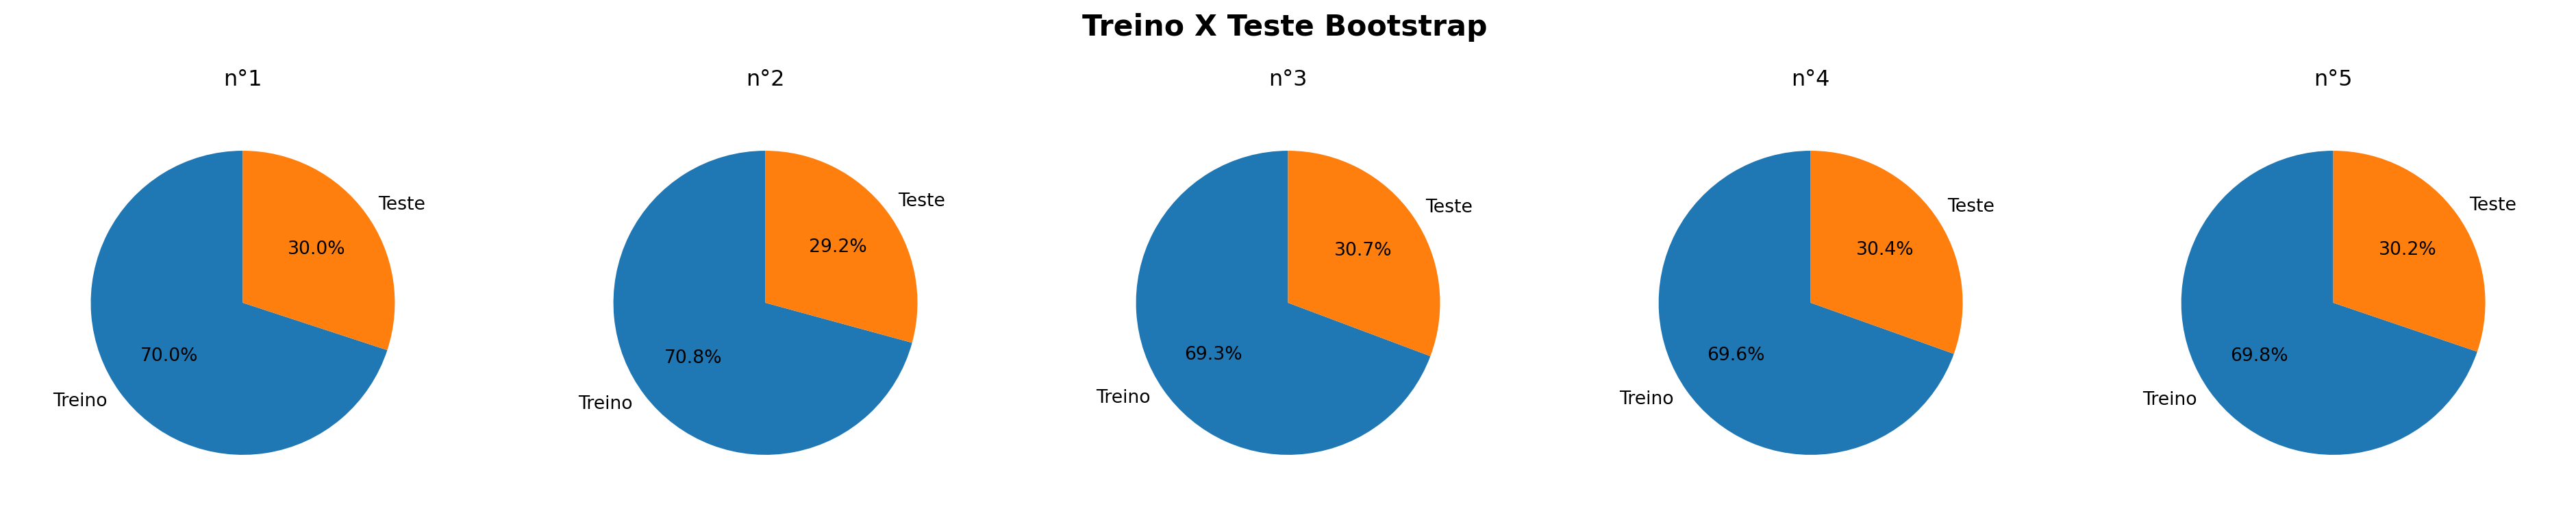

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.subplots_adjust(wspace=0.3)
fig.suptitle('Treino X Teste Bootstrap', fontsize=16, fontweight='bold')
for i in range(len(RepeatedBootstrapSpam)):
    #Removendo as duplicatas
    BootstrapSemDup = list(set(list(RepeatedBootstrapSpam[i][1].index)))
    BootstrapETeste = [len(BootstrapSemDup), YSpam.shape[0] - len(BootstrapSemDup)]
    print(BootstrapETeste)
    axes[i].pie(
        BootstrapETeste,
        labels=['Treino', 'Teste'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10}
    )
    axes[i].axis('equal')
    axes[i].set_title(f'n°{i+1}', fontsize=12)

plt.tight_layout()
plt.show()

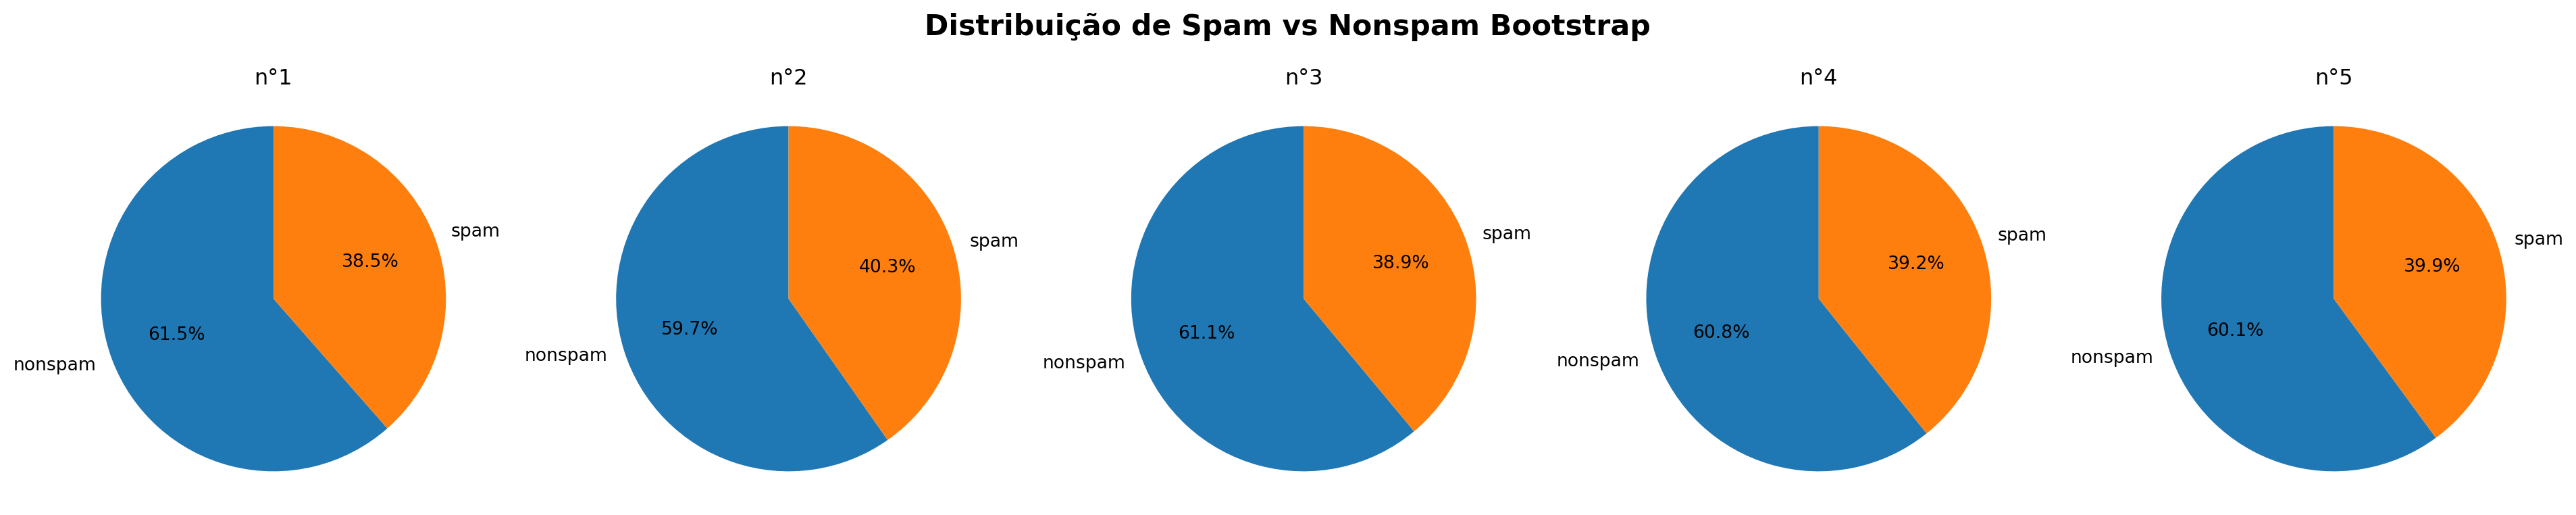

In [11]:
"""for i in range(len(RepeatedBootstrapSpam)):
    contagem = RepeatedBootstrapSpam[i][1].value_counts()
    plt.figure(figsize=(6, 6))
    plt.pie(contagem.values, labels=contagem.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Distribuição de Spam vs Nonspam Bootstrap n°{i+1}')
    plt.axis('equal')  # Para manter o formato circular
    plt.tight_layout()
    #plt.show()
"""

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.subplots_adjust(wspace=0.3)
fig.suptitle('Distribuição de Spam vs Nonspam Bootstrap', fontsize=16, fontweight='bold')
for i in range(len(RepeatedBootstrapSpam)):
    contagem = RepeatedBootstrapSpam[i][1].value_counts()
    axes[i].pie(
        contagem.values,
        labels=contagem.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10}
    )
    axes[i].axis('equal')
    axes[i].set_title(f'n°{i+1}', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
kfSpam = StratifiedKFold(n_splits=10, shuffle=True, random_state=11)
#podemos usar a função com o repeated k-fold também
#repeatedKfSpam = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=11)
resultadoVC = cross_val_score(RandomForestClassifier(), XSpam, YSpam, cv=kfSpam, scoring="accuracy") 
print(resultadoVC)
print("Média:", resultadoVC.mean())
print("Desvio padrão:", resultadoVC.std())

[0.94360087 0.94565217 0.9673913  0.95434783 0.94782609 0.93695652
 0.9673913  0.97391304 0.95869565 0.95217391]
Média: 0.9547948693765917
Desvio padrão: 0.011317223265379938


In [13]:
def testeMetricasKFold(XBase, YBase, n_splits, random_state, funcaoAlgoritmo):
  """Função para testar acurácia, sensibilidade e especificidade de uma dada base passando por reamostragem por k-fold usando o algoritmo inserido"""
  # criação de uma lista para reutilização do generator 
  kfBase = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state).split(XBase, YBase)
  kfBaseLista = list(kfBase)
  
  # Salvando apenas os índices dos folds em listas [[[treino], [teste]], [[treino], [teste]], ...]  
  foldsBase = []
  for K, (train, test) in enumerate(kfBaseLista, 1):
    # Não guarda K porque não precisa, é o índice da lista mais 1.
    foldsBase.append([list(train), list(test)])
    #print("K:", K, "train:", len(train), "test:", len(test))
  
  # Criando os modelos individuais de cada fold
  modelosIndividuais = []
  for fold in foldsBase:
    modelosIndividuais.append(funcaoAlgoritmo(random_state=random_state).fit(XBase.iloc[fold[0]], YBase.iloc[fold[0]]))

  # Testando os modelos individuais de cada fold
  acuraciaModelos = []
  sensibilidadeModelos = []
  especificidadeModelos = []
  for i in range(len(modelosIndividuais)):
    Y_predBase = modelosIndividuais[i].predict(XBase.iloc[foldsBase[i][1]])
    vn, fp, fn, vp = confusion_matrix(YBase.iloc[foldsBase[i][1]], Y_predBase).ravel()
    acuracia = (vp + vn) / (vp + vn + fp + fn)
    sensibilidade = vp / (vp + fn)
    especificidade = vn / (vn + fp)
    acuraciaModelos.append(acuracia)
    sensibilidadeModelos.append(sensibilidade)
    especificidadeModelos.append(especificidade)
  
  # Printando o compilado de métricas
  print(f"Média da acurácia: {(sum(acuraciaModelos)/len(acuraciaModelos)*100):.1f}%")
  print(f"Desvio padrão populacional da acurácia: {np.std(acuraciaModelos, ddof=0):.3f}\n")
  print(f"Média da sensibilidade: {(sum(sensibilidadeModelos)/len(sensibilidadeModelos)*100):.1f}%")
  print(f"Desvio padrão populacional da sensibilidade: {np.std(sensibilidadeModelos, ddof=0):.3f}\n")
  print(f"Média da especificidade: {(sum(especificidadeModelos)/len(especificidadeModelos)*100):.1f}%")
  print(f"Desvio padrão populacional da especificidade: {np.std(especificidadeModelos, ddof=0):.3f}\n")

In [14]:
testeMetricasKFold(XSpam, YSpam, n_splits=5, random_state=11, funcaoAlgoritmo=RandomForestClassifier)

Média da acurácia: 95.1%
Desvio padrão populacional da acurácia: 0.010

Média da sensibilidade: 92.4%
Desvio padrão populacional da sensibilidade: 0.014

Média da especificidade: 96.8%
Desvio padrão populacional da especificidade: 0.008

